### 💾💻📊 Data Science - MMI Portfolio No. 3
# 💥 Sentiment Analysis (NLP + Machine Learning) 💥



An extremely common dataset for benchmarking, method development, and tutorials is **MNIST** consisting of handwritten digits. In reference to this dataset several variants appeared such as sign-MNIST (photos of hand gestures for sign language), audioMNIST (audiofiles of spoken digits) and **fashionMNIST** made of low resolution photos of 10 types of clothes. We will here use this tp explore different possibilities for using dimensionality reduction techniques.

Please complete the following exercises:
## 1. Data Exploration and Cleaning
- Select equal number of reviews for all possible ratings (1 to 5).
- Use suitable Python libraries to detect the language for every restaurant review, for instance `langdetect`.
- Show a distribution of detected languages.
- Continue to work only with English entries.

Hint: This could take a little while, so better use `tqdm` or similar to show the progress.

## 2. TF-IDF + Logistic Regression vs Linear Regression
- Use the `TfidfVectorizer` to create vectors of all remaining reviews.
- Train a Logistic Regression model on the 5 rating classes
- Train a Linear Regression model on the rating (1 to 5).
- Compare both models, which works better?
- Also compare single tokens vs. 1 + 2-grams (`ngrams = (1,2)`), which works better?
- Show the 10 most relevant words (or ngrams) for predicting high or low ratings.

## 3. Language Model --> word vectors + Logistic Regression
- Use Spacy and a larger English language model (`spacy.load("en_core_web_lg")`) to create vectors for each review. This might take a while so use a progress bar, for instance like this:
```python
vectors = []
for review in tqdm(reviews):
    doc = nlp(review)
    vectors.append(doc.vector)

# --> then change to numpy array
```
- Train a Logistic Regression model on the review embeddings to predict the 5 rating classes. 
- Evaluate the performance when compared to the TF-IDF case before.

## 4. Dimensionality reduction
- Run a UMAP dimensionality reduction on the spacy document vectors.
- Create a scatter plot and color each point by `rating_review`.
- Evalute the result: did this dimensionality reduction work as expected? What do we actually see in the plot?



## General instructions
- The final notebook should be executable in the correct order (this means it should work if you do `Kernel` --> `Restart kernel and run all cells...`)
- Just providing code and plots is not enough, you should document and comment where necessary. Not so much on small code-related things (you may still do this if you want though, but this is not required), but mostly to explain what you do, why you do it, what you observe.

More specifically:
- Please briefly comment on the changes you make to the data, in particular if you apply complex operations or if your changes depend on a certain choice you have to make.
- Please add descriptions and/or interpretations to the results you generate (for instance tables, plots). This doesn't have to be a lot of text. For simple, easy-to-understand results, a brief sentence can be enough. For more complex results, you might want to add a bit more explanation.

---
Please add your Name here
## Name: Sander Tebeck

---

## Imports and helper function
Use this part to import the main libraries used in this notebook.  
Also add more complex helper functions to this part (if you use any).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy

from tqdm.notebook import tqdm

from langdetect import detect, DetectorFactory
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error


from sklearn.linear_model import LogisticRegression, LinearRegression

import umap.umap_ as umap 
# add imports if anything is missing
# for instance. feel free to use other plotting libraries (e.g. seaborn, plotly...)

c:\Users\sundl\miniconda3\envs\datascience\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Data download and import
The following analysis should be done with data from TripAdvisor, namely restraurant reviews from **Barcelona**. You can find the respective data (`Barcelona_reviews.csv`) on the [TripAdvisor data](https://zenodo.org/records/6583422).


In [2]:
filename = "data/Barcelona_reviews.csv"
data = pd.read_csv(filename, low_memory=False)
data = data.drop(["Unnamed: 0"], axis=1)
data.head()

,parse_count,restaurant_name,rating_review,sample,review_id,title_review,review_preview,review_full,date,city,url_restaurant,author_id
0,1,Chalito_Rambla,1,Negative,review_774086112,Terrible food Terrible service,"Ok, this place is terrible! Came here bc we’ve...","Ok, this place is terrible! Came here bc we’ve...","October 12, 2020",Barcelona_Catalonia,https://www.tripadvisor.com/Restaurant_Review-...,UID_0
1,2,Chalito_Rambla,5,Positive,review_739142140,The best milanesa in central Barcelona,This place was a great surprise. The food is d...,This place was a great surprise. The food is d...,"January 14, 2020",Barcelona_Catalonia,https://www.tripadvisor.com/Restaurant_Review-...,UID_1
2,3,Chalito_Rambla,5,Positive,review_749758638,Family bonding,The food is excellent.....the ambiance is very...,The food is excellent.....the ambiance is very...,"March 7, 2020",Barcelona_Catalonia,https://www.tripadvisor.com/Restaurant_Review-...,UID_2
3,4,Chalito_Rambla,5,Positive,review_749732001,Best food,"The food is execellent ,affortable price for p...","The food is execellent ,affortable price for p...","March 7, 2020",Barcelona_Catalonia,https://www.tripadvisor.com/Restaurant_Review-...,UID_3
4,5,Chalito_Rambla,5,Positive,review_749691057,Amazing Food and Fantastic Service,"Mr Suarez,The food at your restaurant was abso...","Mr Suarez,The food at your restaurant was abso...","March 7, 2020",Barcelona_Catalonia,https://www.tripadvisor.com/Restaurant_Review-...,UID_4


In [3]:
# Some cleaning
mask = data.rating_review == "Barcelona_Catalonia"
data = data[~mask]
data.rating_review = data.rating_review.astype(int)

## 1. Data Exploration and Cleaning
- Select equal number of reviews for all possible ratings (1 to 5).
- Use suitable Python libraries to detect the language for every restaurant review, for instance `langdetect`.
- Show a distribution of detected languages.
- Continue to work only with English entries.

Hint: This could take a little while, so better use `tqdm` or similar to show the progress.

In [4]:
data.rating_review.value_counts()

rating_review
5    241976
4     96803
3     33148
1     26250
2     18178
Name: count, dtype: int64

Kleinste Menge identifizieren.

In [5]:
min_amount = data.rating_review.value_counts().min()

Nutzen der groupby und sample function, um aus jeder *rating_review* Gruppe (also 1 bis 5) jeweils *min_amount* Einträge in einem neuen DF zu sammeln.

In [6]:
data_balanced = data.groupby('rating_review').sample(n=min_amount, random_state=0)

In [7]:
data_balanced.rating_review.value_counts()

rating_review
1    18178
2    18178
3    18178
4    18178
5    18178
Name: count, dtype: int64

Sprache ermitteln mit langdetect. Für jede Zeile wird die sprache in 'review_full' ermittelt und in die neue Spalte *language* geschrieben.

In [8]:
DetectorFactory.seed = 0

In [9]:
data_balanced['language'] = data_balanced['review_full'].apply(detect)

Um Trotz der großen mengenunterschiede vergleichbarkeit in den seltener Vorkommenden Sprachen zu behalten, wird hier die y achse logaritmisch dargestellt. Um der Verzerrung im Vergleich von den häufigen zu den seltenen Sprachen durch die y-Skalierung gegen zu wirken, wurden die tasächlichen Werte noch über der Bar angegeben.

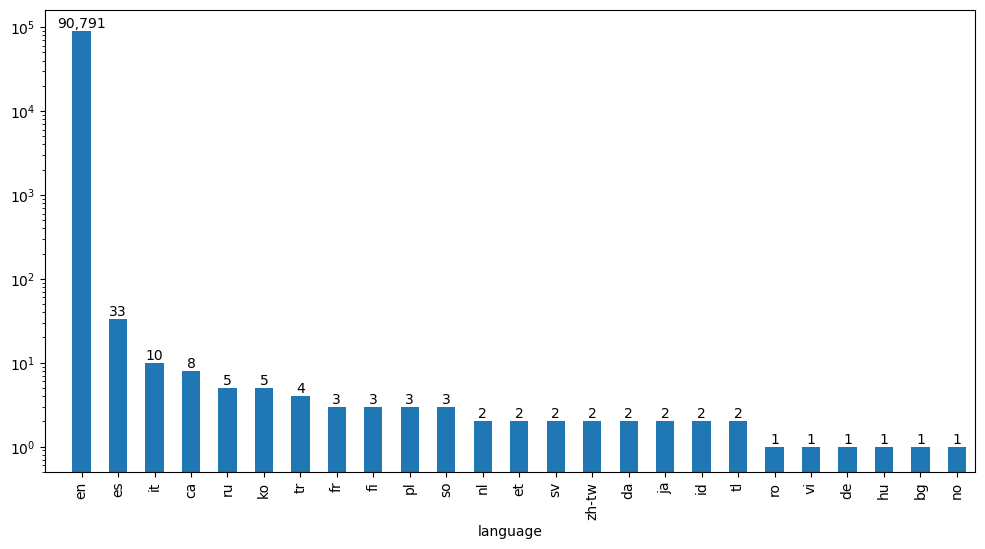

In [10]:
ax =data_balanced.language.value_counts().plot(kind='bar', figsize=(12,6))
ax.set_yscale('log')
ax.axis(ymin=0.5,xmin=-1)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,                        
        f'{int(height):,}',            
        ha='center',                 
        va='bottom',                  
        fontsize=10
    )

Reduzierung auf den englischen Teil des Datensatzes:

In [11]:
en_data = data_balanced[data_balanced['language'] == 'en']

## 2. TF-IDF + Logistic Regression vs Linear Regression
- Use the `TfidfVectorizer` to create vectors of all remaining reviews.
- Train a Logistic Regression model on the 5 rating classes
- Train a Linear Regression model on the rating (1 to 5).
- Compare both models, which works better?
- Also compare single tokens vs. 1 + 2-grams (`ngrams = (1,2)`), which works better?
- Show the 10 most relevant words (or ngrams) for predicting high or low ratings.

Train test Split:

In [12]:
X = en_data['review_full']
y = en_data['rating_review']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=0)

Initialisierung des Tfidf Vectorizer mit min df von 5 und max df von 0.5. Dass heißt ein !!!!!!!!! musss mindestens 5 mal vorkommen, aber in unter 50% der Texte. So können zu seltene und zu häufige Worter rausgelassen werden. Nach der Initialisierung wird der Vectorizer auf den Trainingsdaten gefittet und Trasnformiert diese direkt. Der Vectorizer transformt die Testdaten nur.

In [13]:
tfidf = TfidfVectorizer(
    min_df=5,
    max_df=0.5,
)

X_train_tfidf_vectors = tfidf.fit_transform(X_train)
X_test_tfidf_vectors = tfidf.transform(X_test)

Code zum plotten von Confusion matrixen:

In [14]:
def plot_confusion_matrix(confusion_matrix):
    """ Simple plot of a confusion matrix using Seaborn's heatmap."""
    plt.figure(figsize=(6, 4), dpi=100)
    sb.heatmap(confusion_matrix, annot=True, annot_kws={"size": 16},
                cmap="Purples",
                fmt="g")

    # Set labels and title
    plt.xlabel('Predicted', fontsize=16)
    plt.ylabel('Actual', fontsize=16)
    plt.title('Confusion Matrix', fontsize=20)

Initialisierung und Fitting vom LogisticRegression Modell:

In [15]:
model_log_reg = LogisticRegression(max_iter=500)

model_log_reg.fit(X_train_tfidf_vectors,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


Prediction durch das Modell auf den Testvektoren und plotten der Ergebnisse.Zur etwas besseren Vergleichbarkeit mit dem folgendem Regressionsmodell wurde auch MAE berechnet.

              precision    recall  f1-score   support

           1       0.68      0.72      0.70      5397
           2       0.50      0.47      0.49      5455
           3       0.54      0.53      0.54      5487
           4       0.55      0.55      0.55      5509
           5       0.69      0.71      0.70      5390

    accuracy                           0.60     27238
   macro avg       0.59      0.60      0.59     27238
weighted avg       0.59      0.60      0.59     27238

Mean Average Error:  0.4666642191056612


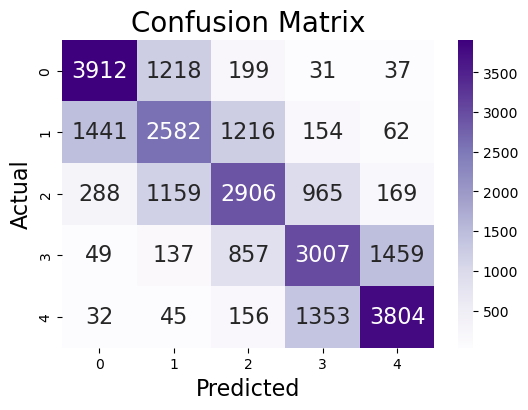

In [16]:
prediction = model_log_reg.predict(X_test_tfidf_vectors)
prediction_proba = model_log_reg.predict_proba(X_test_tfidf_vectors)

print(classification_report(y_test, prediction))

conf_matrix = confusion_matrix(y_test, prediction)
plot_confusion_matrix(conf_matrix)
print('Mean Average Error: ',mean_absolute_error(y_test,prediction))

Initialisierung und Fitting vom LinearRegression Modell:

In [17]:
model_lin_reg = LinearRegression()

model_lin_reg.fit(X_train_tfidf_vectors,y_train.astype('float'))

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
prediction = model_lin_reg.predict(X_test_tfidf_vectors)

In [19]:
mean_absolute_error(y_test,prediction)

0.6607196178323947

In [21]:
linearPredicitons = pd.DataFrame({'y_test': y_test, 'prediction': prediction})

Um einen zusätzlichen Vergleich zu MAE zu haben hab ich die Dichte der Predictions geplottet

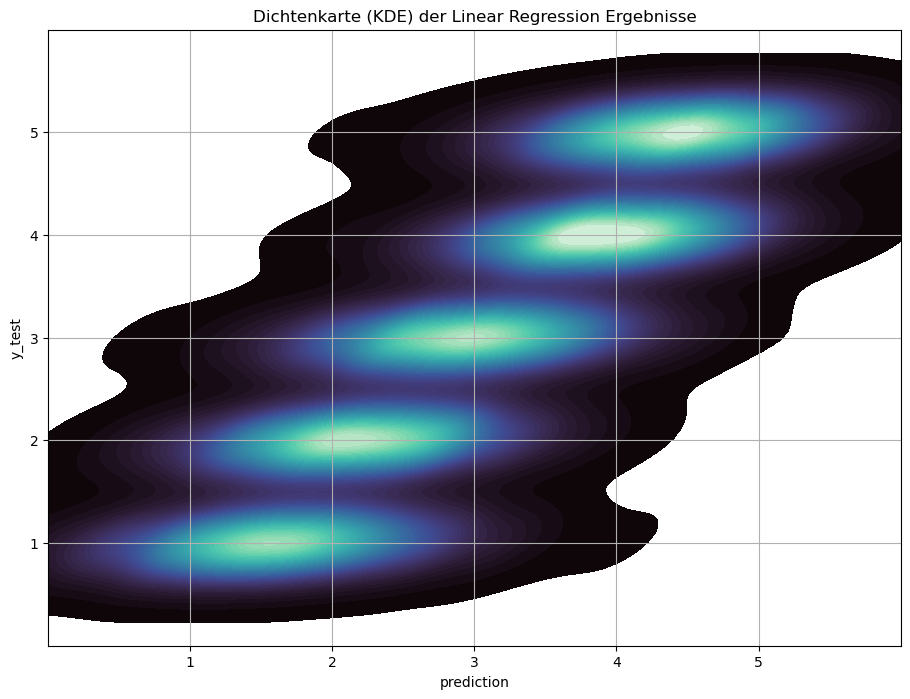

In [28]:
plt.figure(figsize=(11, 8))
sb.kdeplot(
    data=linearPredicitons,
    x="prediction",
    y="y_test",
    fill=True,          # Flächenfüllung statt nur Linien
    cmap="mako",        # Farbskala
    thresh=0.005,        # Schwelle zum Anzeigen
    levels=50          # Glätte der Darstellung
)
plt.title("Dichtenkarte (KDE) der Linear Regression Ergebnisse")
plt.yticks([1,2,3,4,5])
plt.xticks([1,2,3,4,5])
plt.ylim((0,6))
plt.xlim((0,6))
plt.grid(visible=True)
plt.show()

c:\Users\sundl\miniconda3\envs\datascience\Lib\site-packages\seaborn\utils.py:105: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scout = method(scout_x, scout_y, **kws)
c:\Users\sundl\miniconda3\envs\datascience\Lib\site-packages\seaborn\relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


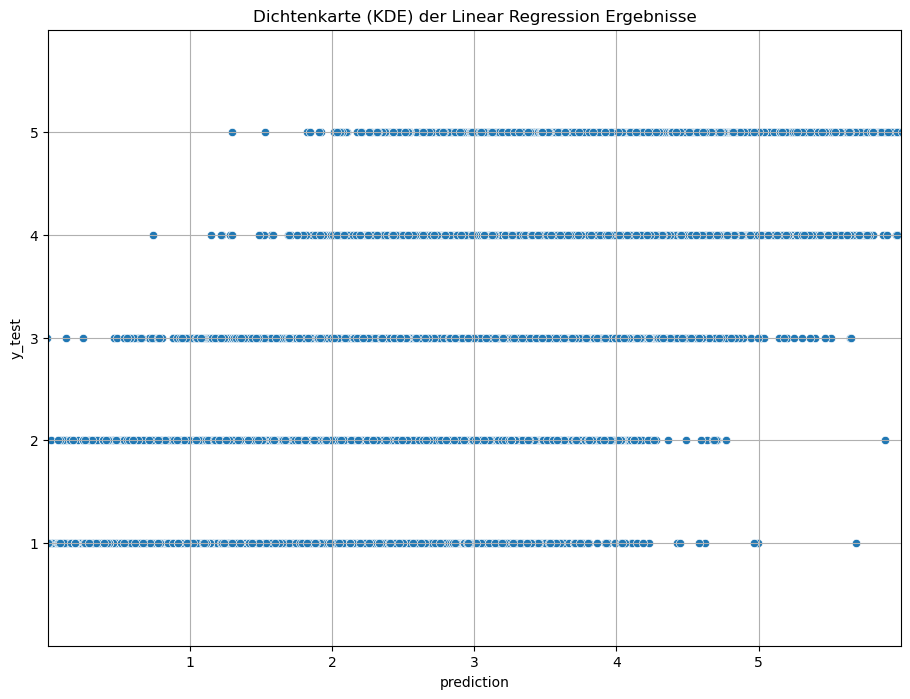

In [ ]:
plt.figure(figsize=(11, 8))
sb.violinplot(
    data=linearPredicitons,
    x="prediction",
    y="y_test",        # Flächenfüllung statt nur Linien
    cmap="mako"     # Glätte der Darstellung
)
plt.title("Dichtenkarte (KDE) der Linear Regression Ergebnisse")
plt.yticks([1,2,3,4,5])
plt.xticks([1,2,3,4,5])
plt.ylim((0,6))
plt.xlim((0,6))
plt.grid(visible=True)
plt.show()

### Vergleich des Logistic and Linear Regression Modell: 

Aufgrund der natürlichen unterschiede zwischen Klassifikations und Regressionsmodellen, ist ein direkter vergleich nicht umbedingt klar. Der Mean Average Error lag beim LogisticRegression deutlich niedriger. Allerdings muss beim Vergleich mittels MAE beachtet werden das der Maximal Fehler bei einem LinearRegression Modell unendlich groß sein kann und beim LogisticRegression Maximal bei 4 liegt. Das lineare Modell kann also auch Unsinnige werte vorhersagen die unter 1 oder über 5 sind. Aufgrund der Natur der Problemstellung ist ein LogisticRegression Modell einem einfachem LinearRegression Modell vorzuziehen. 

Erneute Initialisierung eines Vectorizers mit Ngrams:

In [22]:
tfidf_Ngrams = TfidfVectorizer(
    min_df=5,
    max_df=0.5,
    ngram_range=(1,2),
)

X_train_tfidf_Ngrams_vectors = tfidf_Ngrams.fit_transform(X_train)
X_test_tfidf_Ngrams_vectors = tfidf_Ngrams.transform(X_test)

Modell init und fit:

In [23]:
model_ngrams = LogisticRegression(max_iter=500)
model_ngrams.fit(X_train_tfidf_Ngrams_vectors,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


Prediction und Modell tests:

              precision    recall  f1-score   support

           1       0.69      0.73      0.71      5397
           2       0.52      0.49      0.51      5455
           3       0.57      0.55      0.56      5487
           4       0.57      0.57      0.57      5509
           5       0.70      0.72      0.71      5390

    accuracy                           0.61     27238
   macro avg       0.61      0.61      0.61     27238
weighted avg       0.61      0.61      0.61     27238



0.4387987370585212

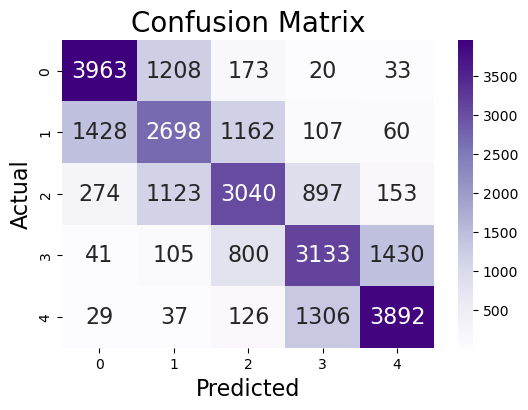

In [24]:
prediction = model_ngrams.predict(X_test_tfidf_Ngrams_vectors)

print(classification_report(y_test, prediction))

conf_matrix = confusion_matrix(y_test, prediction)
plot_confusion_matrix(conf_matrix)
mean_absolute_error(y_test,prediction)

### Vergleich n-grams vs no n-grams

Wenn man ein Blick auf die Classification Summaries wirft, kann man sehen, dass das N-gram Modell eine kleine aber eindeutige verbesserung aufweißt. Die Accuracy steigt um 1% auf 61%, der f1 score steigt bei den Klassen 3 und 4 um 0,2. 

### Wichtige Wörter:

In [25]:
pos_idx = np.argsort(model_ngrams.coef_)[0, :10]
neg_idx = np.argsort(model_ngrams.coef_)[0, -10:]
print("Top 10 positve words:", tfidf_Ngrams.get_feature_names_out()[pos_idx])
print("Top 10 negative words:", tfidf_Ngrams.get_feature_names_out()[neg_idx])

Top 10 positve words: ['good' 'great' 'delicious' 'excellent' 'friendly' 'tasty' 'amazing'
 'nice' 'bit' 'atmosphere']
Top 10 negative words: ['not' 'no' 'disgusting' 'horrible' 'rude' 'bad' 'awful' 'avoid'
 'terrible' 'worst']


In [26]:
pos_idx = np.argsort(model_log_reg.coef_)[0, :10]
neg_idx = np.argsort(model_log_reg.coef_)[0, -10:]
print("Top 10 positve words:", tfidf.get_feature_names_out()[pos_idx])
print("Top 10 negative words:", tfidf.get_feature_names_out()[neg_idx])

Top 10 positve words: ['good' 'delicious' 'great' 'excellent' 'amazing' 'tasty' 'friendly'
 'enjoyed' 'best' 'bit']
Top 10 negative words: ['disgusting' 'not' 'poor' 'bad' 'rude' 'horrible' 'avoid' 'awful'
 'terrible' 'worst']


Was fällt auf? Keine 2 n grams im Ngramm modell

## 3. Language Model --> word vectors + Logistic Regression
- Use Spacy and a larger English language model (`spacy.load("en_core_web_lg")`) to create vectors for each review. This might take a while so use a progress bar, for instance like this:
```python
vectors = []
for review in tqdm(reviews):
    doc = nlp(review)
    vectors.append(doc.vector)

# --> then change to numpy array
```
- Train a Logistic Regression model on the review embeddings to predict the 5 rating classes. 
- Evaluate the performance when compared to the TF-IDF case before.

In [27]:
tqdm.pandas()

Hier musste ich en_core_web_sm nutzen, da en_core_web_lg den jupyter Kernel zum abstürzen brachte.

In [89]:
nlp = spacy.load("en_core_web_sm")

In [29]:
X_train_vectors = []
for review in X_train:
    doc = nlp(review)
    X_train_vectors.append(doc.vector)

X_test_vectors = []
for review in X_test:
    doc = nlp(review)
    X_test_vectors.append(doc.vector)

Init und Fit eines neuen LogReg Modell

In [31]:
model_spacy = LogisticRegression(max_iter=500)
model_spacy.fit(X_train_vectors,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


Predictionn und Modell analyse:

              precision    recall  f1-score   support

           1       0.47      0.58      0.52      5397
           2       0.35      0.29      0.32      5455
           3       0.37      0.36      0.37      5487
           4       0.39      0.35      0.37      5509
           5       0.46      0.51      0.48      5390

    accuracy                           0.42     27238
   macro avg       0.41      0.42      0.41     27238
weighted avg       0.41      0.42      0.41     27238



0.9474263896027608

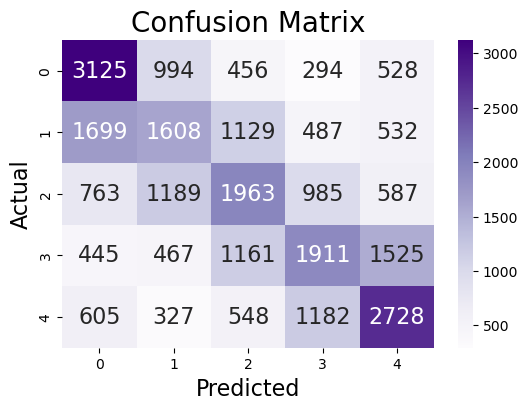

In [32]:
prediction = model_spacy.predict(X_test_vectors)

print(classification_report(y_test, prediction))

conf_matrix = confusion_matrix(y_test, prediction)
plot_confusion_matrix(conf_matrix)
mean_absolute_error(y_test,prediction)

Ergebnis: Modell deutlich schlechter als das TFidf verfahren.

## 4. Dimensionality reduction
- Run a UMAP dimensionality reduction on the spacy document vectors.
- Create a scatter plot and color each point by `rating_review`.
- Evalute the result: did this dimensionality reduction work as expected? What do we actually see in the plot?

In [65]:
from sklearn.preprocessing import normalize

In [91]:
spacy_vectors = normalize(X_train_vectors)

In [98]:
umap_reducer = umap.UMAP(n_components=2, n_neighbors=50, n_jobs=-1, init='pca', metric='cosine')
images_train_umap = umap_reducer.fit_transform(spacy_vectors[:30000])

C:\Users\sundl\AppData\Local\Temp\ipykernel_31832\3684660072.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


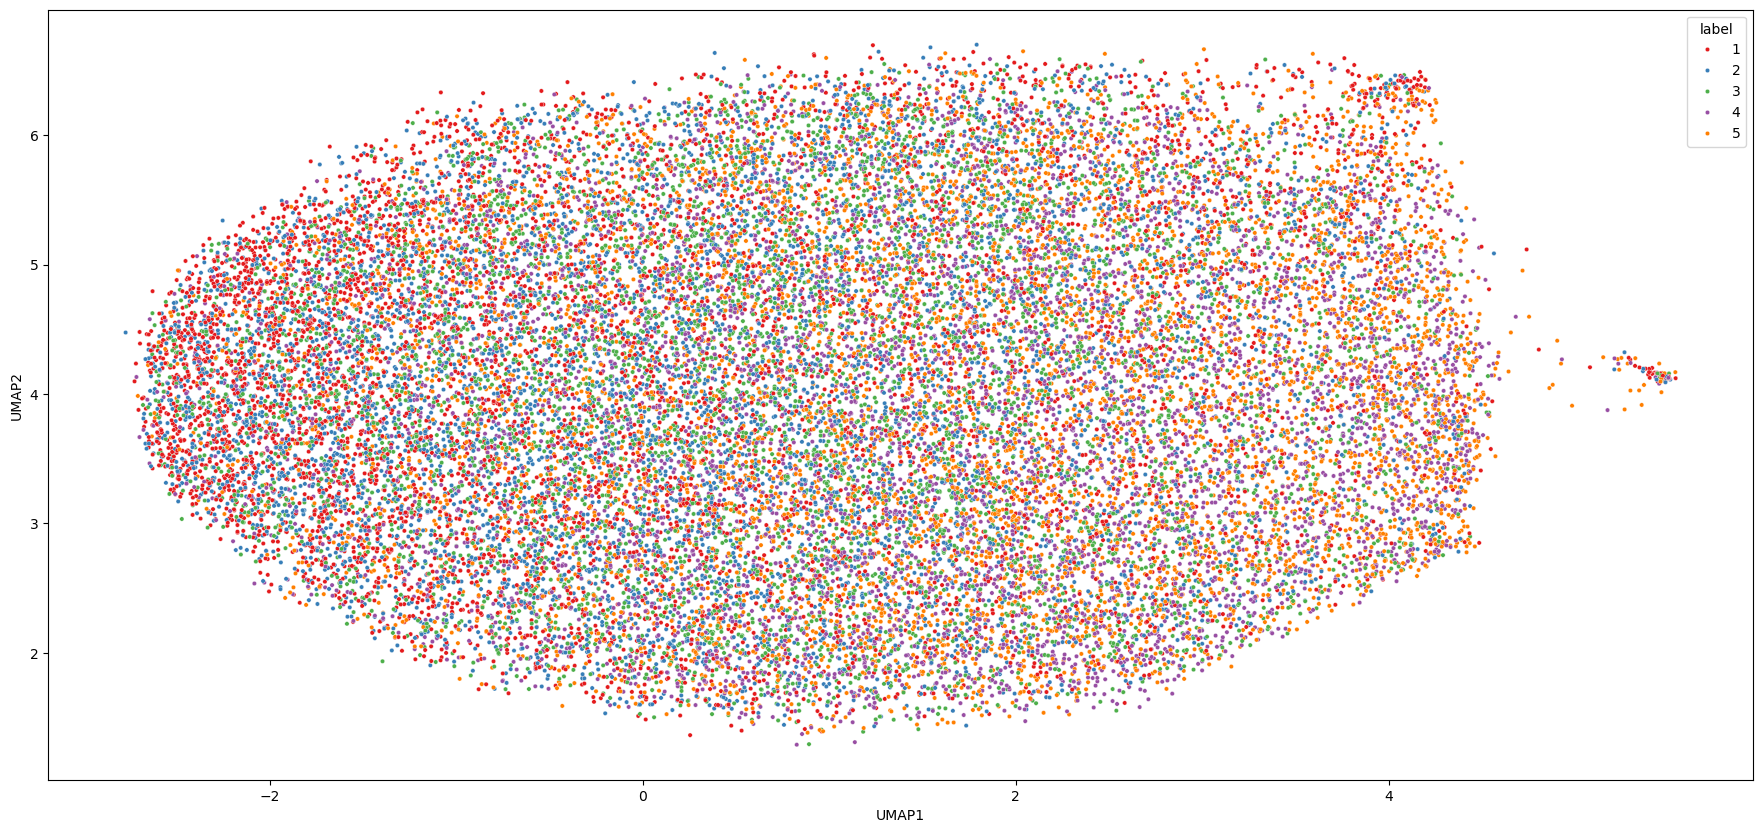

In [99]:
umap_data = pd.DataFrame(images_train_umap)
umap_data["label"]= y_train[:30000].values
umap_data = umap_data.rename(columns={0: "UMAP1", 1: "UMAP2"})

fig, axs = plt.subplots(figsize=(22, 10))
sb.scatterplot(data=umap_data,
                x="UMAP1",
                y="UMAP2",
                hue="label",
                palette= 'Set1',
                s=10)
fig.show()


Das Mappen der Umap Reduzierungsergebnisse der Spacy Document Vectors führt zu keinem klaren Visuellen Cluster Trennung. Die Verschiedenen Datenpunkte sind in einer Wolke fast Homogen verteilt. An der linken Seite der Wolke gibt es eine höhere Dichte an 1er Bewertungen.   